# Schizophrenia Linguistic Study — Research v5.1 FINAL MATCHED

**Final pre-presentation analysis freeze candidate.**

v5 analyses are retained, with one correction:
- the ineffective lexical-topic overlap threshold analysis is replaced by **1:1 nearest-neighbor lexical-topic matching without replacement**.

Primary analysis remains the leakage-controlled author-level Reddit model.  
Topic matching is a sensitivity analysis addressing gross topic/source separation; it cannot fully eliminate subreddit confounding because positive and negative labels originate from different subreddit sources.

In [ ]:
# ============================================================
# 0. ENVIRONMENT CHECK — 설치를 최소화해 Colab 충돌 방지
# ============================================================
import sys, subprocess, importlib.util

print("Python:", sys.version)

# Colab에 없는 패키지만 설치합니다.
needed = {
    "statsmodels": "statsmodels",
    "tqdm": "tqdm",
}
missing = [pip_name for mod, pip_name in needed.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

# IMPORTANT:이
# sentence-transformers / transformers를 설치하지 않습니다.
# Colab의 torch + transformers + sympy 조합 충돌을 피하기 위해
# semantic coherence는 sklearn TF-IDF cosine geometry로 계산합니다.
# 이는 외부 모델 다운로드 없이 Reddit과 DAIS-C에 동일한 extractor를 적용할 수 있습니다.

import os, re, math, random, warnings, zipfile, shutil, tempfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    balanced_accuracy_score, f1_score
)
from sklearn.model_selection import StratifiedGroupKFold

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

WORK = Path("/content/schizophrenia_research_v3")
OUT = WORK / "outputs"
CACHE = WORK / "cache"
DAISC_ROOT = WORK / "daisc_extracted"
for p in [WORK, OUT, CACHE, DAISC_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("Environment ready.")
print("Output folder:", OUT)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Environment ready.
Output folder: /content/schizophrenia_research_v3/outputs


## 1. Reddit CSV 업로드

실행하면 파일 선택창이 뜹니다. Reddit CSV **하나만 선택**하면 됩니다.

In [ ]:
# ============================================================
# 1. UPLOAD REDDIT CSV
# ============================================================
from google.colab import files

print("Reddit CSV 파일을 선택하세요.")
uploaded = files.upload()

csv_names = [name for name in uploaded if name.lower().endswith(".csv")]
if len(csv_names) != 1:
    raise ValueError(f"CSV 파일 1개를 업로드해주세요. 감지된 CSV: {csv_names}")

REDDIT_CSV = Path("/content") / csv_names[0]
REDDIT_CSV.write_bytes(uploaded[csv_names[0]])

raw = pd.read_csv(REDDIT_CSV)

required = {'id','title','selftext','author','subreddit','is_schizophrenic'}
missing = required - set(raw.columns)
if missing:
    raise ValueError(f"필수 column이 없습니다: {missing}\n현재 columns: {list(raw.columns)}")

for c in ['title','selftext','author','subreddit']:
    raw[c] = raw[c].fillna('').astype(str)

raw['text_raw'] = (raw['title'].str.strip() + '\n' + raw['selftext'].str.strip()).str.strip()
raw['label'] = raw['is_schizophrenic'].astype(int)
raw['word_count'] = raw['text_raw'].str.findall(r"\b[\w'-]+\b").str.len()

print("\nLoaded:", REDDIT_CSV.name)
print("Posts:", len(raw), "| Authors:", raw.author.nunique())
display(pd.crosstab(raw['subreddit'], raw['label'], margins=True))

Reddit CSV 파일을 선택하세요.


Saving Copy of Reddit-Based Schizophrenia Detection Dataset.csv to Copy of Reddit-Based Schizophrenia Detection Dataset.csv

Loaded: Copy of Reddit-Based Schizophrenia Detection Dataset.csv
Posts: 15844 | Authors: 11563


label,0,1,All
subreddit,,,
Jokes,2672,0,2672
Meditation,338,0,338
Parenting,879,0,879
relationships,2629,0,2629
schizophrenia,0,9222,9222
teaching,104,0,104
All,6622,9222,15844


## 2. Dataset audit + 분석 대상 정의

여기서는 **subreddit–label confounding을 숨기지 않고 먼저 확인**합니다.  
또한 discourse feature가 의미 있으려면 어느 정도 길이가 필요하므로 너무 짧은 글은 제외합니다.

직접적인 진단/정신증/약물 단어는 masking한 버전을 primary sensitivity dataset으로 사용합니다.

In [ ]:
# ============================================================
# 2. AUDIT + PREPROCESSING
# ============================================================
MIN_WORDS = 80
MAX_WORDS = 1200

DIRECT_TERMS = [
    r"schizophren\w*", r"schizo\w*", r"psychosis", r"psychotic",
    r"antipsychotic\w*", r"neuroleptic\w*", r"haloperidol", r"clozapine",
    r"olanzapine", r"risperidone", r"quetiapine", r"aripiprazole",
    r"diagnos\w*", r"hallucinat\w*", r"delusion\w*", r"hearing voices?"
]
DIRECT_RE = re.compile(r"\b(?:" + "|".join(DIRECT_TERMS) + r")\b", re.I)

def mask_direct_terms(text):
    return DIRECT_RE.sub("MASKTERM", str(text))

source_table = pd.crosstab(raw['subreddit'], raw['label'], margins=True)
source_table.to_csv(OUT/"Table_0_subreddit_label_audit.csv")

df = raw.loc[
    raw.author.ne('') &
    raw.author.ne('[deleted]') &
    raw.word_count.between(MIN_WORDS, MAX_WORDS)
].copy()

df['text_masked'] = df.text_raw.map(mask_direct_terms)
df['n_masked_terms'] = df.text_raw.map(lambda x: len(DIRECT_RE.findall(x)))

summary = (
    df.groupby('label')
      .agg(posts=('id','size'),
           authors=('author','nunique'),
           median_words=('word_count','median'),
           mean_words=('word_count','mean'))
      .reset_index()
)
display(summary)
summary.to_csv(OUT/"Table_1_reddit_characteristics.csv", index=False)

print("Eligible posts:", len(df))
print("Eligible unique authors:", df.author.nunique())
print("\nDirect diagnosis/symptom term present:")
display(pd.crosstab(df.label, df.n_masked_terms > 0, margins=True))

,label,posts,authors,median_words,mean_words
0,0,2700,2693,179.0,222.017778
1,1,2250,1873,127.0,163.870667


Eligible posts: 4950
Eligible unique authors: 4566

Direct diagnosis/symptom term present:


n_masked_terms,False,True,All
label,,,
0,2620,80,2700
1,418,1832,2250
All,3038,1912,4950


## 3. Cross-domain linguistic features

To avoid Colab transformer dependency failures and to keep the extractor identical across corpora, v4 uses deterministic within-document TF-IDF geometry.

### Primary structural/discourse features
- `adj_semantic_distance`: adjacent-window **lexical/discourse distance**
- `semantic_drift_slope`: change in distance from the first window across the document
- `max_semantic_drift`: maximum first-window distance
- `mattr50`: moving-average type-token ratio
- `avg_word_length`
- `first_person_ratio`
- `function_word_ratio`
- `conjunction_ratio`

The historical variable names are retained for code compatibility, but in the presentation describe the first three as **TF-IDF-based discourse/lexical coherence measures**, not as direct measures of clinical thought disorder.

### Secondary content feature
- `paranoia_content_ratio`

The content feature is excluded from the primary structural model.

In [ ]:
# ============================================================
# 3. FEATURE EXTRACTOR — NO TRANSFORMERS REQUIRED
# ============================================================
TOKEN_RE = re.compile(r"\b[a-zA-Z][a-zA-Z'-]*\b")

FIRST_PERSON = {'i','me','my','mine','myself','we','us','our','ours','ourselves'}
FUNCTION_WORDS = {
    'the','a','an','and','or','but','if','then','because','while','although',
    'to','of','in','on','at','for','from','with','without','by','as',
    'is','am','are','was','were','be','been','being','do','does','did',
    'have','has','had','can','could','will','would','shall','should','may','might','must',
    'this','that','these','those','it','its','he','she','they','them','his','her','their',
    'i','me','my','we','us','our','you','your'
}
CONJUNCTIONS = {
    'and','or','but','because','although','though','while','whereas',
    'however','therefore','so','yet','if','unless','since'
}
PARANOIA_TERMS = {
    'government','police','cia','fbi','stalking','stalked','watching','tracking',
    'poison','poisoned','control','controlled','camera','cameras','conspiracy',
    'agent','agents','hacked','hacking','surveillance','spying','spy'
}

def toks(text):
    return TOKEN_RE.findall(str(text).lower())

def mattr(tok, window=50):
    if not tok: return np.nan
    if len(tok) <= window: return len(set(tok))/len(tok)
    return float(np.mean([
        len(set(tok[i:i+window]))/window
        for i in range(len(tok)-window+1)
    ]))

def make_windows(tok, window=40, stride=20):
    if len(tok) < window: return []
    return [' '.join(tok[i:i+window]) for i in range(0, len(tok)-window+1, stride)]

def document_semantic_geometry(text):
    tok = toks(text)
    chunks = make_windows(tok, 40, 20)

    empty_result = {
        'adj_semantic_distance': np.nan,
        'semantic_drift_slope': np.nan,
        'max_semantic_drift': np.nan
    }

    if len(chunks) < 3:
        return empty_result

    try:
        vec = TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=1,
            norm='l2',
            sublinear_tf=True,
            token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z'-]*\b"
        )

        X = vec.fit_transform(chunks)

        if X.shape[1] == 0:
            return empty_result

        adj_sim = np.asarray(
            X[:-1].multiply(X[1:]).sum(axis=1)
        ).ravel()

        adj_dist = 1 - adj_sim

        first_sim = np.asarray(
            X.multiply(X[0]).sum(axis=1)
        ).ravel()

        drift = 1 - first_sim

        if len(drift) < 2:
            return empty_result

        slope = np.polyfit(
            np.arange(len(drift)),
            drift,
            1
        )[0]

        return {
            'adj_semantic_distance': float(np.mean(adj_dist)),
            'semantic_drift_slope': float(slope),
            'max_semantic_drift': float(np.max(drift))
        }

    except ValueError:
        return empty_result

def extract_features(text):
    tok = toks(text)
    n = max(len(tok),1)
    out = {
        'mattr50': mattr(tok,50),
        'avg_word_length': np.mean([len(x) for x in tok]) if tok else np.nan,
        'first_person_ratio': sum(x in FIRST_PERSON for x in tok)/n,
        'function_word_ratio': sum(x in FUNCTION_WORDS for x in tok)/n,
        'conjunction_ratio': sum(x in CONJUNCTIONS for x in tok)/n,
        'paranoia_content_ratio': sum(x in PARANOIA_TERMS for x in tok)/n,
    }
    out.update(document_semantic_geometry(text))
    return out

STRUCTURAL = [
    'adj_semantic_distance','semantic_drift_slope','max_semantic_drift',
    'mattr50','avg_word_length','first_person_ratio',
    'function_word_ratio','conjunction_ratio'
]
CONTENT = ['paranoia_content_ratio']
ALL_FEATURES = STRUCTURAL + CONTENT

print("Feature extractor ready.")

Feature extractor ready.


In [ ]:
# ============================================================
# 4. EXTRACT REDDIT FEATURES
# ============================================================
cache_file = CACHE/"reddit_features.csv"

if cache_file.exists():
    feat = pd.read_csv(cache_file)
else:
    rows = []
    for _, r in tqdm(df.iterrows(), total=len(df), desc="Reddit features"):
        f = extract_features(r.text_masked)
        f.update({
            'id':r.id, 'author':r.author, 'subreddit':r.subreddit,
            'label':int(r.label), 'word_count':int(r.word_count),
            'n_masked_terms':int(r.n_masked_terms)
        })
        rows.append(f)
    feat = pd.DataFrame(rows)
    feat.to_csv(cache_file,index=False)

print("Feature table:", feat.shape)
display(feat.head())

Reddit features:   0%|          | 0/4950 [00:00<?, ?it/s]

Feature table: (4950, 15)


,mattr50,avg_word_length,first_person_ratio,function_word_ratio,conjunction_ratio,paranoia_content_ratio,adj_semantic_distance,semantic_drift_slope,max_semantic_drift,id,author,subreddit,label,word_count,n_masked_terms
0,0.885116,5.550562,0.000000,0.028090,0.016854,0.000000,0.494437,0.137944,0.966942,7hy1bs,calculust_,schizophrenia,1,181,10
1,0.906667,5.800000,0.000000,0.011765,0.011765,0.000000,0.564405,0.491651,0.983302,8y0y7p,rodnahs,schizophrenia,1,87,0
2,0.928333,5.814433,0.000000,0.010309,0.010309,0.020619,0.564347,0.487768,0.975536,1gu660i,Coolfrogpenguin,schizophrenia,1,98,2
3,0.916818,5.729282,0.016575,0.033149,0.005525,0.000000,0.498482,0.105897,0.982028,14qt9rv,6626e-37,relationships,0,187,0
4,0.884600,5.604027,0.013423,0.073826,0.000000,0.013423,0.485953,0.171386,0.965632,4rlhrq,throwawaydsifojd,relationships,0,152,0


,feature,label1_mean,control_mean,hedges_g,g_ci_low,g_ci_high,welch_p,fdr_p,family
4,avg_word_length,5.701946,5.451438,0.640050,0.569701,0.711438,1.199908e-87,1.079917e-86,structural
5,first_person_ratio,0.006698,0.012404,-0.548312,-0.637810,-0.446388,3.940989e-72,1.773445e-71,structural
1,semantic_drift_slope,0.254087,0.172905,0.537158,0.470869,0.598302,8.658728e-66,2.597618e-65,structural
0,adj_semantic_distance,0.513693,0.502266,0.446973,0.350161,0.545731,1.052984e-43,2.369214e-43,structural
8,paranoia_content_ratio,0.002705,0.000784,0.439916,0.381539,0.496972,1.097099e-37,1.974779e-37,content
6,function_word_ratio,0.037259,0.047151,-0.333291,-0.409914,-0.260239,1.507323e-27,2.260985e-27,structural
2,max_semantic_drift,0.970181,0.977882,-0.216489,-0.278250,-0.162331,1.933239e-11,2.485593e-11,structural
7,conjunction_ratio,0.008485,0.009626,-0.132529,-0.192833,-0.073000,1.199382e-05,1.349305e-05,structural
3,mattr50,0.874256,0.875504,-0.025039,-0.082107,0.033111,4.119640e-01,4.119640e-01,structural


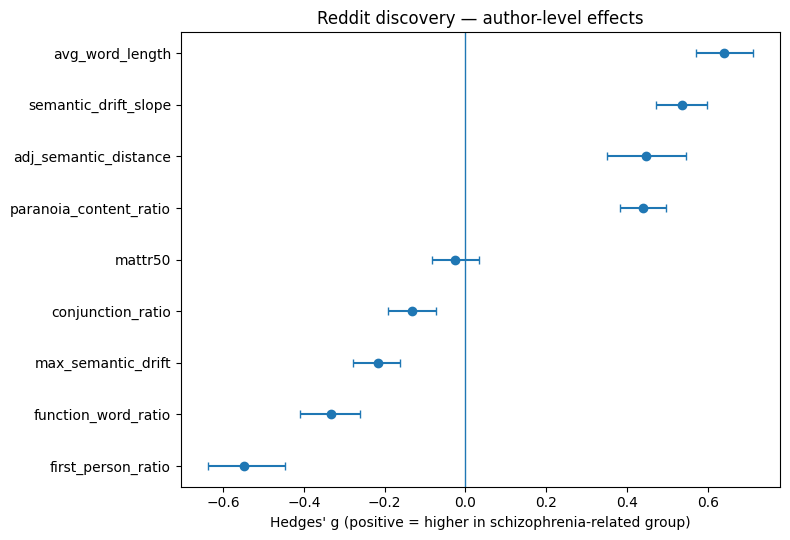

In [ ]:
# ============================================================
# 5. AUTHOR-LEVEL STATISTICS + FDR
# ============================================================
def hedges_g(a,b):
    a=np.asarray(pd.Series(a).dropna(),float)
    b=np.asarray(pd.Series(b).dropna(),float)
    if len(a)<2 or len(b)<2: return np.nan
    va,vb=np.var(a,ddof=1),np.var(b,ddof=1)
    sp=np.sqrt(((len(a)-1)*va+(len(b)-1)*vb)/(len(a)+len(b)-2))
    if sp==0: return 0.
    d=(np.mean(a)-np.mean(b))/sp
    J=1-3/(4*(len(a)+len(b))-9)
    return J*d

def boot_g(a,b,B=1000):
    rng=np.random.default_rng(SEED)
    a=np.asarray(pd.Series(a).dropna(),float)
    b=np.asarray(pd.Series(b).dropna(),float)
    vals=[]
    for _ in range(B):
        vals.append(hedges_g(
            rng.choice(a,len(a),replace=True),
            rng.choice(b,len(b),replace=True)
        ))
    return np.percentile(vals,[2.5,97.5])

author = feat.groupby(['author','label'],as_index=False)[ALL_FEATURES].mean()

rows=[]
for f in ALL_FEATURES:
    a=author.loc[author.label==1,f].dropna()
    b=author.loc[author.label==0,f].dropna()
    t,p=stats.ttest_ind(a,b,equal_var=False,nan_policy='omit')
    g=hedges_g(a,b); lo,hi=boot_g(a,b)
    rows.append([f,a.mean(),b.mean(),g,lo,hi,p])

stat_table=pd.DataFrame(rows,columns=[
    'feature','label1_mean','control_mean','hedges_g','g_ci_low','g_ci_high','welch_p'
])
stat_table['fdr_p']=multipletests(stat_table.welch_p,method='fdr_bh')[1]
stat_table['family']=np.where(stat_table.feature.isin(STRUCTURAL),'structural','content')
stat_table.to_csv(OUT/"Table_2_feature_statistics.csv",index=False)
display(stat_table.sort_values('fdr_p'))

p=stat_table.sort_values('hedges_g')
plt.figure(figsize=(8,5.5))
y=np.arange(len(p))
plt.errorbar(
    p.hedges_g,y,
    xerr=[p.hedges_g-p.g_ci_low,p.g_ci_high-p.hedges_g],
    fmt='o',capsize=3
)
plt.axvline(0,linewidth=1)
plt.yticks(y,p.feature)
plt.xlabel("Hedges' g (positive = higher in schizophrenia-related group)")
plt.title("Reddit discovery — author-level effects")
plt.tight_layout()
plt.savefig(OUT/"Figure_1_Reddit_effect_sizes.png",dpi=220)
plt.show()

,model,n_authors,n_posts,AUTHOR_AUROC_PRIMARY,AUTHOR_AUROC_CI_low,AUTHOR_AUROC_CI_high,AUTHOR_AUPRC,AUTHOR_balanced_accuracy_at_0.5,AUTHOR_F1_at_0.5,POST_AUROC_SECONDARY
0,Structural only (PRIMARY),4566,4950,0.781772,0.767845,0.794728,0.685454,0.713693,0.667698,0.777322
1,Content only,4566,4950,0.583475,0.566364,0.600179,0.527031,0.583324,0.391783,0.564775
2,Structural + content,4566,4950,0.801794,0.788481,0.814386,0.713759,0.729790,0.685478,0.796522


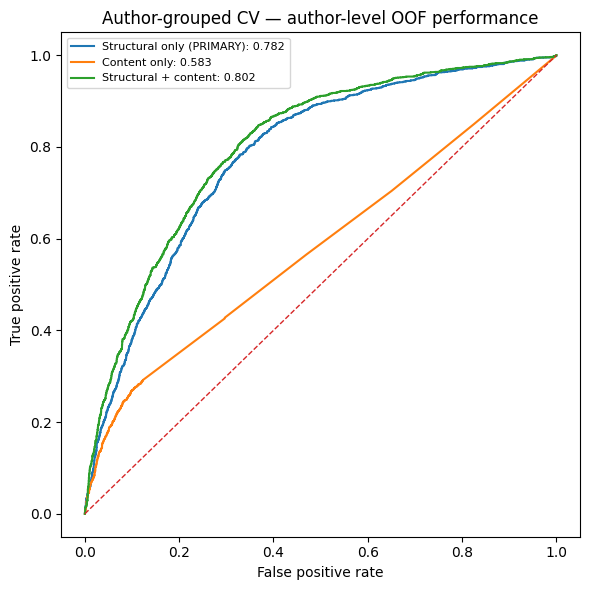

PRIMARY performance unit = unique Reddit author.
Post-level AUROC is retained only as a secondary descriptive metric.


In [ ]:
# ============================================================
# 6. AUTHOR-GROUPED CV + AUTHOR-LEVEL PRIMARY METRICS (v4)
# ============================================================
def grouped_oof(features):
    X = feat[features]
    y = feat.label.astype(int).values
    groups = feat.author.astype(str).values

    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    pred = np.full(len(feat), np.nan)

    for tr, te in cv.split(X, y, groups):
        pipe = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('lr', LogisticRegression(
                max_iter=3000, class_weight='balanced',
                random_state=SEED
            ))
        ])
        pipe.fit(X.iloc[tr], y[tr])
        pred[te] = pipe.predict_proba(X.iloc[te])[:, 1]

    oof = feat[['author','label']].copy()
    oof['prob'] = pred

    # PRIMARY: one observation per author.
    author_oof = (
        oof.groupby(['author','label'], as_index=False)
           .agg(prob=('prob','mean'), n_posts=('prob','size'))
    )
    return oof, author_oof

def simple_auc_ci(y, p, B=2000):
    rng = np.random.default_rng(SEED)
    y = np.asarray(y); p = np.asarray(p)
    vals = []
    for _ in range(B):
        ix = rng.integers(0, len(y), len(y))
        if len(np.unique(y[ix])) == 2:
            vals.append(roc_auc_score(y[ix], p[ix]))
    return np.percentile(vals, [2.5, 97.5])

sets = {
    'Structural only (PRIMARY)': STRUCTURAL,
    'Content only': CONTENT,
    'Structural + content': ALL_FEATURES
}

rows = []
curves = {}
oof_author_tables = {}

for name, fs in sets.items():
    post_oof, a = grouped_oof(fs)
    y = a.label.values
    p = a.prob.values

    auc = roc_auc_score(y, p)
    lo, hi = simple_auc_ci(y, p)
    pred_class = (p >= .5).astype(int)

    # Secondary post-level metric, clearly labeled.
    post_auc = roc_auc_score(post_oof.label.values, post_oof.prob.values)

    rows.append({
        'model': name,
        'n_authors': len(a),
        'n_posts': len(post_oof),
        'AUTHOR_AUROC_PRIMARY': auc,
        'AUTHOR_AUROC_CI_low': lo,
        'AUTHOR_AUROC_CI_high': hi,
        'AUTHOR_AUPRC': average_precision_score(y, p),
        'AUTHOR_balanced_accuracy_at_0.5': balanced_accuracy_score(y, pred_class),
        'AUTHOR_F1_at_0.5': f1_score(y, pred_class),
        'POST_AUROC_SECONDARY': post_auc
    })
    curves[name] = (y, p)
    oof_author_tables[name] = a

perf = pd.DataFrame(rows)
perf.to_csv(OUT/"Table_3_AUTHOR_LEVEL_grouped_CV.csv", index=False)
display(perf)

plt.figure(figsize=(6,6))
for name,(y,p) in curves.items():
    fpr,tpr,_ = roc_curve(y,p)
    plt.plot(fpr,tpr,label=f"{name}: {roc_auc_score(y,p):.3f}")
plt.plot([0,1],[0,1],'--',linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Author-grouped CV — author-level OOF performance")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT/"Figure_2_AUTHOR_LEVEL_grouped_CV_ROC.png",dpi=220)
plt.show()

print("PRIMARY performance unit = unique Reddit author.")
print("Post-level AUROC is retained only as a secondary descriptive metric.")

## 7A. 1:1 lexical-topic matched sensitivity analysis

Because the Reddit label is structurally confounded with subreddit source, this analysis cannot prove that source confounding is absent.

Instead, it asks a narrower question:

> **When schizophrenia-related and control posts are explicitly paired to be as similar as possible in masked lexical-topic space, does structural/discourse signal remain?**

Procedure:
1. Mask direct diagnosis/psychosis vocabulary.
2. Build TF-IDF lexical representation using content words.
3. Reduce to an unsupervised TruncatedSVD topic space.
4. Perform **greedy 1:1 nearest-neighbor matching without replacement** across classes.
5. Exclude poor matches using a data-driven similarity caliper.
6. Re-run the unchanged structural-feature author-grouped classifier.

The notebook reports similarity before/after matching and the retained sample size so matching effectiveness is auditable.

Before matching:
 positive posts: 2250
 control posts : 2700
 topic variance explained: 0.105

Best opposite-class similarity distribution:
count    2250.000
mean        0.721
std         0.069
min         0.496
10%         0.630
25%         0.672
50%         0.723
75%         0.771
90%         0.809
max         0.904
dtype: float64
Matching similarity caliper: 0.672

Matched pairs: 1048


,topic_similarity
count,1048.000000
mean,0.722200
std,0.039382
min,0.672475
10%,0.680243
25%,0.691454
50%,0.712672
75%,0.744539
90%,0.776037
max,0.904032



Matched cohort:


,posts,authors,median_words
label,,,
0,1048,1046,209.0
1,1048,903,138.0


,n_pairs,caliper,median_pair_similarity,mean_pair_similarity,p10_pair_similarity,p90_pair_similarity,svd_explained_variance
0,1048,0.672445,0.712672,0.7222,0.680243,0.776037,0.105232


,analysis,n_posts,n_authors,AUROC,CI_low,CI_high
0,Primary full cohort,4950,4566,0.781772,0.767845,0.794728
1,1:1 lexical-topic matched sensitivity cohort,2096,1949,0.725505,0.702326,0.748191


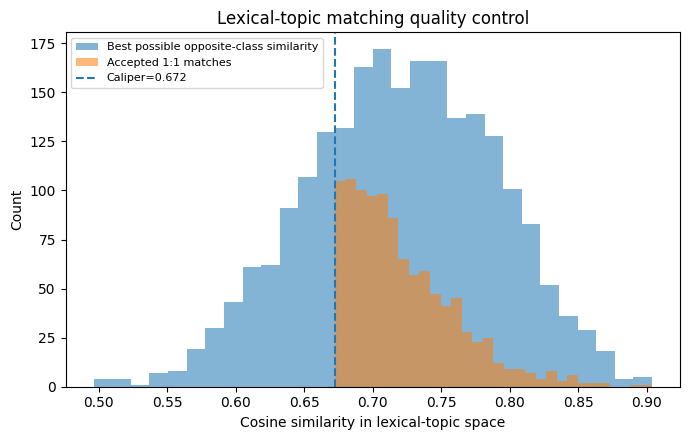


IMPORTANT INTERPRETATION:
This is a sensitivity analysis for gross lexical-topic separation. It does not eliminate subreddit/source confounding.


In [ ]:
# ============================================================
# 7A. 1:1 LEXICAL-TOPIC MATCHING WITHOUT REPLACEMENT — v5.1
# ============================================================
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

TOPIC_MAX_FEATURES = 8000
TOPIC_COMPONENTS = 40
RNG = np.random.default_rng(SEED)

# Use masked text: direct diagnostic vocabulary has already been removed.
topic_vec = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    min_df=5,
    max_df=0.95,
    max_features=TOPIC_MAX_FEATURES,
    ngram_range=(1,2),
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z'-]*\b"
)
Xlex = topic_vec.fit_transform(df.text_masked)

ncomp = min(TOPIC_COMPONENTS, max(2, Xlex.shape[1]-1))
svd = TruncatedSVD(n_components=ncomp, random_state=SEED)
Z = svd.fit_transform(Xlex)
Z = Z / np.maximum(np.linalg.norm(Z, axis=1, keepdims=True), 1e-12)

labels = df.label.astype(int).to_numpy()
pos_idx = np.where(labels==1)[0]
neg_idx = np.where(labels==0)[0]

print("Before matching:")
print(" positive posts:", len(pos_idx))
print(" control posts :", len(neg_idx))
print(" topic variance explained:", round(float(svd.explained_variance_ratio_.sum()),3))

# Full cross-class similarity matrix is feasible for the current ~5k cohort.
S = cosine_similarity(Z[pos_idx], Z[neg_idx])

# Each positive's best possible control similarity (before no-replacement constraint).
best_possible = S.max(axis=1)
print("\nBest opposite-class similarity distribution:")
print(pd.Series(best_possible).describe(percentiles=[.1,.25,.5,.75,.9]).round(3))

# Data-driven caliper:
# retain matches at least as similar as the lower quartile of each positive's
# best attainable opposite-class similarity, with a conservative floor.
caliper = max(0.20, float(np.quantile(best_possible, 0.25)))
print("Matching similarity caliper:", round(caliper,3))

# Greedy matching without replacement.
# Match the hardest positives first (lowest best-available similarity),
# reducing the chance that easy cases consume scarce controls.
order = np.argsort(best_possible)
available = np.ones(len(neg_idx), dtype=bool)
pairs = []

for pi in order:
    candidates = np.where(available)[0]
    if len(candidates)==0:
        break
    sims = S[pi, candidates]
    j_local = int(np.argmax(sims))
    nj = candidates[j_local]
    sim = float(S[pi,nj])

    if sim >= caliper:
        pairs.append((int(pos_idx[pi]), int(neg_idx[nj]), sim))
        available[nj] = False

pairs = pd.DataFrame(pairs, columns=['pos_row','neg_row','topic_similarity'])

if len(pairs) < 100:
    raise RuntimeError(
        f"Only {len(pairs)} matched pairs survived. "
        "Matching is too restrictive; inspect similarity distribution."
    )

print("\nMatched pairs:", len(pairs))
display(pairs.topic_similarity.describe(percentiles=[.1,.25,.5,.75,.9]).to_frame())

# Create matched post cohort.
matched_rows = np.concatenate([pairs.pos_row.values, pairs.neg_row.values])
matched_ids = set(df.iloc[matched_rows].id.astype(str))
feat_matched = feat[feat.id.astype(str).isin(matched_ids)].copy()

matched_summary = feat_matched.groupby('label').agg(
    posts=('id','size'),
    authors=('author','nunique'),
    median_words=('word_count','median')
)
print("\nMatched cohort:")
display(matched_summary)

# Audit topic balance at the pair level.
balance = pd.DataFrame([{
    'n_pairs': len(pairs),
    'caliper': caliper,
    'median_pair_similarity': pairs.topic_similarity.median(),
    'mean_pair_similarity': pairs.topic_similarity.mean(),
    'p10_pair_similarity': pairs.topic_similarity.quantile(.10),
    'p90_pair_similarity': pairs.topic_similarity.quantile(.90),
    'svd_explained_variance': float(svd.explained_variance_ratio_.sum())
}])
display(balance)
balance.to_csv(OUT/"Table_5a_topic_matching_QC.csv", index=False)
pairs.to_csv(OUT/"Table_5b_topic_matched_pairs.csv", index=False)
def grouped_oof_on(data, features):
    X = data[features]
    y = data.label.astype(int).values
    groups = data.author.astype(str).values

    cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    )

    pred = np.full(len(data), np.nan)

    for tr, te in cv.split(X, y, groups):
        pipe = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('lr', LogisticRegression(
                max_iter=3000,
                class_weight='balanced',
                random_state=SEED
            ))
        ])

        pipe.fit(X.iloc[tr], y[tr])
        pred[te] = pipe.predict_proba(X.iloc[te])[:, 1]

    o = data[['author', 'label']].copy()
    o['prob'] = pred

    return (
        o.groupby(['author', 'label'], as_index=False)
         .agg(
             prob=('prob', 'mean'),
             n_posts=('prob', 'size')
         )
    )
# Same structural model, same author-grouped evaluation.
matched_author_oof = grouped_oof_on(feat_matched, STRUCTURAL)
matched_auc = roc_auc_score(matched_author_oof.label, matched_author_oof.prob)
matched_ci = simple_auc_ci(matched_author_oof.label, matched_author_oof.prob)

primary_row = perf.loc[perf.model=='Structural only (PRIMARY)'].iloc[0]

topic_sensitivity = pd.DataFrame([
    {
        'analysis':'Primary full cohort',
        'n_posts':len(feat),
        'n_authors':int(feat.author.nunique()),
        'AUROC':float(primary_row.AUTHOR_AUROC_PRIMARY),
        'CI_low':float(primary_row.AUTHOR_AUROC_CI_low),
        'CI_high':float(primary_row.AUTHOR_AUROC_CI_high)
    },
    {
        'analysis':'1:1 lexical-topic matched sensitivity cohort',
        'n_posts':len(feat_matched),
        'n_authors':int(matched_author_oof.author.nunique()),
        'AUROC':float(matched_auc),
        'CI_low':float(matched_ci[0]),
        'CI_high':float(matched_ci[1])
    }
])
display(topic_sensitivity)
topic_sensitivity.to_csv(OUT/"Table_5c_topic_matched_sensitivity.csv", index=False)

# Visual audit
plt.figure(figsize=(7,4.5))
plt.hist(best_possible, bins=30, alpha=.55, label="Best possible opposite-class similarity")
plt.hist(pairs.topic_similarity, bins=30, alpha=.55, label="Accepted 1:1 matches")
plt.axvline(caliper, linestyle='--', linewidth=1.5, label=f"Caliper={caliper:.3f}")
plt.xlabel("Cosine similarity in lexical-topic space")
plt.ylabel("Count")
plt.title("Lexical-topic matching quality control")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT/"Figure_5_topic_matching_QC.png", dpi=220)
plt.show()

print("\nIMPORTANT INTERPRETATION:")
print(
    "This is a sensitivity analysis for gross lexical-topic separation. "
    "It does not eliminate subreddit/source confounding."
)

## 7B. Author-level label permutation test

The primary structural model is compared with a null distribution obtained by shuffling labels **at the author level** and rerunning grouped cross-validation.  
This preserves the repeated-post structure within each author.

Author-label permutations:   0%|          | 0/200 [00:00<?, ?it/s]

,observed_author_AUROC,permutations,null_mean_AUROC,null_sd_AUROC,permutation_p
0,0.781772,200,0.499328,0.011845,0.004975


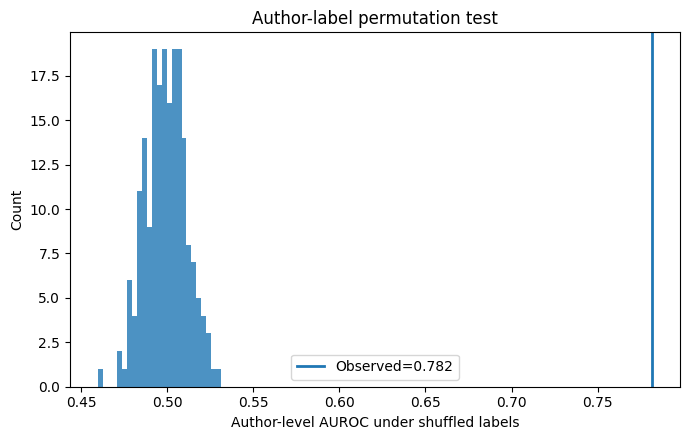

In [ ]:
# ============================================================
# 7B. AUTHOR-LABEL PERMUTATION TEST
# ============================================================
N_PERM = 200

def author_level_cv_auc_with_labels(data, author_label_map, seed):
    d = data.copy()
    y = d.author.astype(str).map(author_label_map).astype(int).values
    groups = d.author.astype(str).values
    X = d[STRUCTURAL]

    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    pred = np.full(len(d), np.nan)

    for tr,te in cv.split(X,y,groups):
        pipe = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('lr', LogisticRegression(max_iter=3000,class_weight='balanced',random_state=seed))
        ])
        pipe.fit(X.iloc[tr],y[tr])
        pred[te] = pipe.predict_proba(X.iloc[te])[:,1]

    tmp = pd.DataFrame({'author':groups,'label':y,'prob':pred})
    a = tmp.groupby(['author','label'],as_index=False).prob.mean()
    return roc_auc_score(a.label,a.prob)

author_truth = feat[['author','label']].drop_duplicates('author').copy()
assert author_truth.author.is_unique

observed_auc = float(
    perf.loc[perf.model=='Structural only (PRIMARY)','AUTHOR_AUROC_PRIMARY'].iloc[0]
)

rng = np.random.default_rng(SEED)
authors = author_truth.author.astype(str).to_numpy()
true_labels = author_truth.label.astype(int).to_numpy()

perm_aucs = []
for b in tqdm(range(N_PERM), desc="Author-label permutations"):
    shuffled = rng.permutation(true_labels)
    amap = dict(zip(authors, shuffled))
    perm_aucs.append(author_level_cv_auc_with_labels(feat, amap, SEED+b+1))

perm_aucs = np.asarray(perm_aucs)
perm_p = (1 + np.sum(perm_aucs >= observed_auc)) / (N_PERM + 1)

perm_summary = pd.DataFrame([{
    'observed_author_AUROC': observed_auc,
    'permutations': N_PERM,
    'null_mean_AUROC': perm_aucs.mean(),
    'null_sd_AUROC': perm_aucs.std(ddof=1),
    'permutation_p': perm_p
}])
display(perm_summary)
perm_summary.to_csv(OUT/"Table_6_author_label_permutation.csv",index=False)

plt.figure(figsize=(7,4.5))
plt.hist(perm_aucs,bins=25,alpha=.8)
plt.axvline(observed_auc,linewidth=2,label=f"Observed={observed_auc:.3f}")
plt.xlabel("Author-level AUROC under shuffled labels")
plt.ylabel("Count")
plt.title("Author-label permutation test")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"Figure_4_author_label_permutation.png",dpi=220)
plt.show()

## 7C. Pretrained embedding coherence robustness analysis

This optional robustness analysis uses the **Universal Sentence Encoder (USE)** as a pretrained encoder.  
No schizophrenia labels are used to fit the encoder.

If TensorFlow Hub/model download is unavailable in the current Colab runtime, the cell records the analysis as skipped rather than breaking the notebook. TF-IDF coherence remains the primary reproducible analysis.

In [ ]:
# ============================================================
# 7C. PRETRAINED USE EMBEDDING COHERENCE — ROBUSTNESS
# ============================================================
USE_URL = "https://tfhub.dev/google/universal-sentence-encoder/4"
EMBED_SAMPLE_PER_CLASS = 800   # computationally practical robustness sample

embedding_result = None

try:
    import tensorflow_hub as hub
    use_model = hub.load(USE_URL)

    rng = np.random.default_rng(SEED)
    sampled_parts = []
    for lab,g in df.groupby('label'):
        n = min(EMBED_SAMPLE_PER_CLASS, len(g))
        sampled_parts.append(g.sample(n=n, random_state=SEED))
    emb_df = pd.concat(sampled_parts,ignore_index=True)

    def use_geometry(text):
        tok = toks(text)
        chunks = make_windows(tok,40,20)
        if len(chunks) < 3:
            return {'use_adj_distance':np.nan,'use_drift_slope':np.nan,'use_max_drift':np.nan}
        E = np.asarray(use_model(chunks))
        E = E / np.maximum(np.linalg.norm(E,axis=1,keepdims=True),1e-12)
        adj = 1 - np.sum(E[:-1]*E[1:],axis=1)
        drift = 1 - E.dot(E[0])
        return {
            'use_adj_distance':float(np.mean(adj)),
            'use_drift_slope':float(np.polyfit(np.arange(len(drift)),drift,1)[0]),
            'use_max_drift':float(np.max(drift))
        }

    erows = []
    for _,r in tqdm(emb_df.iterrows(),total=len(emb_df),desc="USE coherence"):
        q = use_geometry(r.text_masked)
        q.update({'id':r.id,'author':r.author,'label':int(r.label)})
        erows.append(q)
    emb_feat = pd.DataFrame(erows)

    # Author-level descriptive effect sizes; robustness, not model tuning.
    outrows = []
    for f in ['use_adj_distance','use_drift_slope','use_max_drift']:
        aa = emb_feat.loc[emb_feat.label==1,f].dropna()
        bb = emb_feat.loc[emb_feat.label==0,f].dropna()
        t,pv = stats.ttest_ind(aa,bb,equal_var=False,nan_policy='omit')
        gg = hedges_g(aa,bb)
        lo,hi = boot_g(aa,bb,B=2000)
        outrows.append({'feature':f,'hedges_g':gg,'g_ci_low':lo,'g_ci_high':hi,'welch_p':pv})
    embedding_result = pd.DataFrame(outrows)
    embedding_result['fdr_p'] = multipletests(embedding_result.welch_p,method='fdr_bh')[1]
    display(embedding_result)
    embedding_result.to_csv(OUT/"Table_7_USE_embedding_coherence_robustness.csv",index=False)

except Exception as e:
    print("USE robustness analysis skipped:", repr(e))
    pd.DataFrame([{'status':'skipped','reason':repr(e)}]).to_csv(
        OUT/"Table_7_USE_embedding_coherence_robustness_SKIPPED.csv",index=False
    )

USE coherence:   0%|          | 0/1600 [00:00<?, ?it/s]

,feature,hedges_g,g_ci_low,g_ci_high,welch_p,fdr_p
0,use_adj_distance,0.273524,0.176718,0.373976,6.798181e-08,1.019727e-07
1,use_drift_slope,0.544435,0.444165,0.653365,3.355376e-26,1.006613e-25
2,use_max_drift,-0.086587,-0.184166,0.013490,8.620995e-02,8.620995e-02


# 7. DAIS-C ZIP 업로드

이제 **DAIS-C 전체 ZIP 파일 하나만 선택**하세요.

파일이 많아도 괜찮습니다. ZIP을 직접 풀 필요 없습니다.

코드는:
1. `/content/...`에 자동 압축 해제
2. 모든 하위 폴더 재귀 탐색
3. `speaker only raw` 우선
4. `CL / clinical` → clinical label
5. `CO / comparison` → control label

순서로 처리합니다.

압축 내부 구조가 예상과 다르면, 발견된 폴더/파일을 출력하고 **분석을 억지로 진행하지 않고 멈춥니다.**

In [ ]:
# ============================================================
# 7. UPLOAD + EXTRACT DAIS-C ZIP
# ============================================================
print("DAIS-C corpus ZIP 파일을 선택하세요.")
daisc_uploaded = files.upload()

zip_names=[n for n in daisc_uploaded if n.lower().endswith('.zip')]
if len(zip_names)!=1:
    raise ValueError(f"ZIP 파일 1개를 업로드해주세요. 감지된 ZIP: {zip_names}")

zip_path=Path('/content')/zip_names[0]
zip_path.write_bytes(daisc_uploaded[zip_names[0]])

if DAISC_ROOT.exists():
    shutil.rmtree(DAISC_ROOT)
DAISC_ROOT.mkdir(parents=True)

with zipfile.ZipFile(zip_path,'r') as z:
    # Basic zip-slip protection
    root_resolved=DAISC_ROOT.resolve()
    for member in z.infolist():
        target=(DAISC_ROOT/member.filename).resolve()
        if root_resolved not in target.parents and target != root_resolved:
            raise ValueError("Unsafe ZIP path detected.")
    z.extractall(DAISC_ROOT)

all_files=[p for p in DAISC_ROOT.rglob('*') if p.is_file()]
print("Extracted files:",len(all_files))
print("\nTop-level extracted items:")
for p in list(DAISC_ROOT.iterdir())[:30]:
    print(" -",p.name)

DAIS-C corpus ZIP 파일을 선택하세요.


Saving DAIS.zip to DAIS.zip
Extracted files: 123

Top-level extracted items:
 - DAIS-C-Annotated-Upload


In [ ]:
# ============================================================
# 8. DAIS-C PARTICIPANT FILE DISCOVERY + QC (v4)
# ============================================================
TEXT_EXTS = {'.txt','.text','.xml'}

def label_from_path(path):
    s = str(path).lower().replace('\\','/')
    if 'dai-c-cl' in s:
        return 1
    if 'dai-c-co' in s:
        return 0
    return None

text_files = [
    p for p in DAISC_ROOT.rglob('*')
    if p.is_file() and p.suffix.lower() in TEXT_EXTS
]

# Use only the actual raw speaker folder.
speaker_raw = [
    p for p in text_files
    if 'speaker only_raw' in str(p).lower().replace('\\','/')
]

# DAIS-C individual raw files observed in the uploaded corpus follow:
# DDMMMYY_Raw.txt-like alphanumeric IDs, e.g. 21AN11_Raw.txt.
# Exclude aggregate resources such as WMatrix-full-clinical-raw.txt.
participant_pattern = re.compile(r'^[0-9]{2}[A-Za-z]{2}[0-9]{2}_Raw\.txt$', re.I)

participant_files = [
    p for p in speaker_raw
    if participant_pattern.match(p.name)
]

excluded_raw = [p for p in speaker_raw if p not in participant_files]

labeled = [
    (p, label_from_path(p))
    for p in participant_files
    if label_from_path(p) is not None
]

manifest = pd.DataFrame({
    'participant_id': [p.stem.replace('_Raw','').replace('_raw','') for p,l in labeled],
    'path': [str(p) for p,l in labeled],
    'group': ['clinical' if l==1 else 'comparison' for p,l in labeled]
})

print("All text/XML files:", len(text_files))
print("Files in Speaker Only_Raw folders:", len(speaker_raw))
print("Individual participant raw files:", len(labeled))
print("\nActual participant counts in uploaded raw corpus:")
display(manifest.groupby('group').size().rename('n').to_frame())

if excluded_raw:
    print("\nExcluded non-participant raw resources:")
    for p in excluded_raw:
        print(" -", p.name)

dups = manifest.participant_id.duplicated().sum()
print("\nDuplicate participant IDs:", dups)
if dups:
    raise RuntimeError("Duplicate DAIS-C participant IDs detected; inspect manifest before analysis.")

if len(manifest) == 0 or manifest.group.nunique() != 2:
    raise RuntimeError("Could not identify both DAIS-C participant groups.")

manifest.to_csv(OUT/"DAISC_participant_manifest_v4.csv", index=False)

print(
    "\nQC NOTE: v4 reports the N actually present in the uploaded Speaker Only_Raw folders. "
    "It does not invent or force a missing participant."
)

All text/XML files: 58
Files in Speaker Only_Raw folders: 29
Individual participant raw files: 28

Actual participant counts in uploaded raw corpus:


,n
group,
clinical,15
comparison,13



Excluded non-participant raw resources:
 - WMatrix-full-clinical-raw.txt

Duplicate participant IDs: 0

QC NOTE: v4 reports the N actually present in the uploaded Speaker Only_Raw folders. It does not invent or force a missing participant.


DAIS-C participant features:   0%|          | 0/28 [00:00<?, ?it/s]

Usable participant-level DAIS-C transcripts: 28


,participants,median_words,mean_words
label,,,
0,13,1616.0,1983.923077
1,15,2900.0,3698.066667


,feature,clinical_mean,comparison_mean,daisc_g,g_ci_low,g_ci_high,welch_p,fdr_p,reddit_g,direction_concordant,abs_reddit_g,abs_daisc_g
6,function_word_ratio,0.389863,0.419192,-0.867671,-1.749700,-0.174585,0.025434,0.101735,-0.333291,True,0.333291,0.867671
4,avg_word_length,3.819613,3.982874,-0.945221,-1.979898,-0.228035,0.016304,0.101735,0.640050,False,0.640050,0.945221
2,max_semantic_drift,0.992331,0.982912,0.783317,0.158844,1.610873,0.057827,0.154206,-0.216489,False,0.216489,0.783317
5,first_person_ratio,0.074633,0.063201,0.600784,-0.091879,1.398389,0.114047,0.228095,-0.548312,False,0.548312,0.600784
0,adj_semantic_distance,0.467573,0.465508,0.259891,-0.461543,1.041647,0.484389,0.553587,0.446973,True,0.446973,0.259891
1,semantic_drift_slope,0.010227,0.003106,0.260258,-1.096016,0.617697,0.459454,0.553587,0.537158,True,0.537158,0.260258
7,conjunction_ratio,0.062616,0.066244,-0.276455,-0.909292,0.496329,0.448500,0.553587,-0.132529,True,0.132529,0.276455
3,mattr50,0.710837,0.710448,0.011056,-0.849858,0.746848,0.976292,0.976292,-0.025039,False,0.025039,0.011056


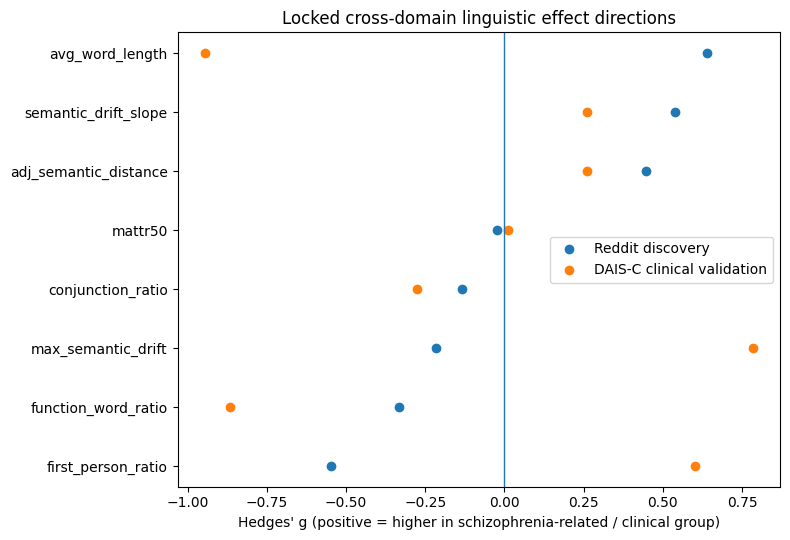

Direction concordance: 4/8 (50.0%)
Interpret direction concordance descriptively because DAIS-C is small.


In [ ]:
# ============================================================
# 9. DAIS-C PARTICIPANT-LEVEL EXTERNAL VALIDATION (v4)
# ============================================================
def read_flexible(p):
    for enc in ['utf-8','utf-8-sig','cp1252','latin-1']:
        try:
            return Path(p).read_text(encoding=enc)
        except Exception:
            pass
    return ''

def clean_transcript(x):
    x = re.sub(r'<[^>]+>', ' ', x)
    x = re.sub(r'\s+', ' ', x)
    return x.strip()

rows = []
for p,label in tqdm(labeled, desc="DAIS-C participant features"):
    text = clean_transcript(read_flexible(p))
    ntok = len(toks(text))
    if ntok < MIN_WORDS:
        print("Excluded for short transcript:", p.name, ntok, "words")
        continue

    f = extract_features(mask_direct_terms(text))
    f.update({
        'participant_id': p.stem.replace('_Raw','').replace('_raw',''),
        'speaker_file': p.name,
        'label': int(label),
        'word_count': ntok
    })
    rows.append(f)

daisc = pd.DataFrame(rows)

if daisc.participant_id.duplicated().any():
    raise RuntimeError("Participant duplication remains after parsing.")

print("Usable participant-level DAIS-C transcripts:", len(daisc))
daisc_counts = (
    daisc.groupby('label')
         .agg(participants=('participant_id','nunique'),
              median_words=('word_count','median'),
              mean_words=('word_count','mean'))
)
display(daisc_counts)
daisc_counts.to_csv(OUT/"Table_4a_DAISC_sample_characteristics.csv")

# Locked external validation: all structural features are tested;
# no DAIS-C-driven feature selection.
ext_rows = []
for f in STRUCTURAL:
    a = daisc.loc[daisc.label==1, f].dropna()
    b = daisc.loc[daisc.label==0, f].dropna()
    t,p = stats.ttest_ind(a,b,equal_var=False,nan_policy='omit')
    g = hedges_g(a,b)
    lo,hi = boot_g(a,b,B=5000)
    ext_rows.append({
        'feature': f,
        'clinical_mean': a.mean(),
        'comparison_mean': b.mean(),
        'daisc_g': g,
        'g_ci_low': lo,
        'g_ci_high': hi,
        'welch_p': p
    })

ext = pd.DataFrame(ext_rows)
ext['fdr_p'] = multipletests(ext.welch_p, method='fdr_bh')[1]

reddit_effect = (
    stat_table.loc[stat_table.feature.isin(STRUCTURAL), ['feature','hedges_g']]
              .rename(columns={'hedges_g':'reddit_g'})
)
ext = ext.merge(reddit_effect,on='feature',how='left')
ext['direction_concordant'] = np.sign(ext.daisc_g) == np.sign(ext.reddit_g)
ext['abs_reddit_g'] = ext.reddit_g.abs()
ext['abs_daisc_g'] = ext.daisc_g.abs()

ext.to_csv(OUT/"Table_4b_DAISC_LOCKED_external_validation.csv",index=False)
display(ext.sort_values('fdr_p'))

# Cross-domain figure
p = ext.sort_values('reddit_g')
y = np.arange(len(p))
plt.figure(figsize=(8,5.5))
plt.scatter(p.reddit_g,y,label='Reddit discovery')
plt.scatter(p.daisc_g,y,label='DAIS-C clinical validation')
plt.axvline(0,linewidth=1)
plt.yticks(y,p.feature)
plt.xlabel("Hedges' g (positive = higher in schizophrenia-related / clinical group)")
plt.title("Locked cross-domain linguistic effect directions")
plt.legend()
plt.tight_layout()
plt.savefig(OUT/"Figure_3_Reddit_vs_DAISC_v4.png",dpi=220)
plt.show()

n_conc = int(ext.direction_concordant.sum())
print(f"Direction concordance: {n_conc}/{len(ext)} ({ext.direction_concordant.mean():.1%})")
print("Interpret direction concordance descriptively because DAIS-C is small.")

## 10. Interpretation rules for the 10/24 presentation

### Primary results
1. **Reddit author-level feature effects** after direct diagnosis-term masking.
2. **Author-level OOF AUROC** from author-grouped cross-validation.
3. **Locked DAIS-C participant-level effect replication**, emphasizing effect sizes, CIs and direction rather than p-value hunting.

### Important limitations to state explicitly
- Reddit label/source is confounded with subreddit and is not equivalent to confirmed clinical diagnosis.
- TF-IDF window distance measures lexical/discourse coherence, not a validated biological or diagnostic biomarker.
- Reddit is written language whereas DAIS-C is transcribed speech.
- DAIS-C is small; its role is external signal validation rather than model training.
- The uploaded DAIS-C `Speaker Only_Raw` corpus may contain a different usable participant count from the publication; report the **actual analyzed N** and investigate corpus completeness separately.

### Clinical-data extension to propose to the professor
The public-data analysis is treated as a completed discovery + external-validation study.  
The next step is independent validation using local schizophrenia/control interview transcripts, ideally with PANSS and/or formal-thought-disorder severity, enabling:
- replication of locked discourse features,
- symptom-severity correlation,
- adjustment for age/sex/medication/education where available,
- clinically meaningful validation beyond subreddit-derived labels.

In [ ]:
# ============================================================
# 11. 10/24 PRESENTATION SUMMARY + DOWNLOAD RESULTS (v4)
# ============================================================
print("="*72)
print("RESEARCH v5.1 — FINAL MATCHED ROBUSTNESS RESULTS")
print("="*72)

print("\n[1] Reddit author-level linguistic effects")
display(
    stat_table[['feature','hedges_g','g_ci_low','g_ci_high','fdr_p','family']]
    .sort_values('fdr_p')
)

print("\n[2] PRIMARY author-level grouped-CV performance")
display(perf)

print("\n[3] DAIS-C participant-level sample")
display(daisc_counts)

print("\n[4] Locked DAIS-C external validation")
display(
    ext[['feature','reddit_g','daisc_g','g_ci_low','g_ci_high',
         'direction_concordant','fdr_p']]
)

print(
    f"\nCross-domain direction concordance: "
    f"{int(ext.direction_concordant.sum())}/{len(ext)} "
    f"({ext.direction_concordant.mean():.1%})"
)

print("\nPresentation conclusion template:")
print(
    "After controlling same-author leakage and masking direct diagnostic vocabulary, "
    "schizophrenia-related Reddit writing showed measurable discourse/linguistic differences. "
    "A locked subset of these structural features was then evaluated in participant-level "
    "DAIS-C clinical transcripts. The external corpus is small and cross-modal, so replication "
    "is interpreted using effect size and direction rather than as diagnostic accuracy."
)

RESULT_ZIP = WORK/"Research_v5_1_results.zip"
with zipfile.ZipFile(RESULT_ZIP,'w',zipfile.ZIP_DEFLATED) as z:
    for p in OUT.rglob('*'):
        if p.is_file():
            z.write(p,arcname=p.name)

print("\nPackaged:", RESULT_ZIP)
files.download(str(RESULT_ZIP))

RESEARCH v5.1 — FINAL MATCHED ROBUSTNESS RESULTS

[1] Reddit author-level linguistic effects


,feature,hedges_g,g_ci_low,g_ci_high,fdr_p,family
4,avg_word_length,0.640050,0.569701,0.711438,1.079917e-86,structural
5,first_person_ratio,-0.548312,-0.637810,-0.446388,1.773445e-71,structural
1,semantic_drift_slope,0.537158,0.470869,0.598302,2.597618e-65,structural
0,adj_semantic_distance,0.446973,0.350161,0.545731,2.369214e-43,structural
8,paranoia_content_ratio,0.439916,0.381539,0.496972,1.974779e-37,content
6,function_word_ratio,-0.333291,-0.409914,-0.260239,2.260985e-27,structural
2,max_semantic_drift,-0.216489,-0.278250,-0.162331,2.485593e-11,structural
7,conjunction_ratio,-0.132529,-0.192833,-0.073000,1.349305e-05,structural
3,mattr50,-0.025039,-0.082107,0.033111,4.119640e-01,structural



[2] PRIMARY author-level grouped-CV performance


,model,n_authors,n_posts,AUTHOR_AUROC_PRIMARY,AUTHOR_AUROC_CI_low,AUTHOR_AUROC_CI_high,AUTHOR_AUPRC,AUTHOR_balanced_accuracy_at_0.5,AUTHOR_F1_at_0.5,POST_AUROC_SECONDARY
0,Structural only (PRIMARY),4566,4950,0.781772,0.767845,0.794728,0.685454,0.713693,0.667698,0.777322
1,Content only,4566,4950,0.583475,0.566364,0.600179,0.527031,0.583324,0.391783,0.564775
2,Structural + content,4566,4950,0.801794,0.788481,0.814386,0.713759,0.729790,0.685478,0.796522



[3] DAIS-C participant-level sample


...


[4] Locked DAIS-C external validation


,feature,reddit_g,daisc_g,g_ci_low,g_ci_high,direction_concordant,fdr_p
0,adj_semantic_distance,0.446973,0.259891,-0.461543,1.041647,True,0.553587
1,semantic_drift_slope,0.537158,0.260258,-1.096016,0.617697,True,0.553587
2,max_semantic_drift,-0.216489,0.783317,0.158844,1.610873,False,0.154206
3,mattr50,-0.025039,0.011056,-0.849858,0.746848,False,0.976292
4,avg_word_length,0.640050,-0.945221,-1.979898,-0.228035,False,0.101735
5,first_person_ratio,-0.548312,0.600784,-0.091879,1.398389,False,0.228095
6,function_word_ratio,-0.333291,-0.867671,-1.749700,-0.174585,True,0.101735
7,conjunction_ratio,-0.132529,-0.276455,-0.909292,0.496329,True,0.553587



Cross-domain direction concordance: 4/8 (50.0%)

Presentation conclusion template:
After controlling same-author leakage and masking direct diagnostic vocabulary, schizophrenia-related Reddit writing showed measurable discourse/linguistic differences. A locked subset of these structural features was then evaluated in participant-level DAIS-C clinical transcripts. The external corpus is small and cross-modal, so replication is interpreted using effect size and direction rather than as diagnostic accuracy.

Packaged: /content/schizophrenia_research_v3/Research_v5_1_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>